# 02 — Taylor-CNN Training Verification

**Goal:** Connect the verified Taylor gate to a 2-layer 1D CNN and confirm
the full two-channel model can learn to classify transit vs no-transit.

**Success criterion:** Loss decreases over 10 epochs on synthetic data.

## Architecture
```
phase ──→ TaylorGate ──→ gate_out ──┐
                                     ├──→ stack (B, 2, 200)
flux ────────────────────────────────┘         │
                                        Conv1d(2→8, k=7) + ReLU
                                        Conv1d(8→16, k=5) + ReLU
                                        AdaptiveAvgPool → (B, 16)
                                               │
                                        Linear(16, 1) → sigmoid
```
The CNN receives both channels simultaneously — its first-layer filters learn
to compare gate (physics model) vs flux (observed data) at each position.

In [1]:
import sys
sys.path.insert(0, '..')

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

from src.models.taylor_cnn import TaylorCNN
from src.data.synthetic import make_synthetic_batch

print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using: {device}")

PyTorch: 2.12.0.dev20260408+cu128


CUDA: True
Using: cuda


## 1. Inspect the model

Before training, let's look at what we built — parameter count, layer
shapes, and a sanity-check forward pass.

In [2]:
model = TaylorCNN(init_amplitude=0.01)
print(model)
print()

# Count parameters by component
taylor_params = sum(p.numel() for p in model.taylor_gate.parameters())
cnn_params = sum(p.numel() for p in model.cnn.parameters())
classifier_params = sum(p.numel() for p in model.classifier.parameters())
total_params = sum(p.numel() for p in model.parameters())

print(f"Taylor gate:  {taylor_params:>5} params  (just amplitude A)")
print(f"CNN layers:   {cnn_params:>5} params  (2 conv layers)")
print(f"Classifier:   {classifier_params:>5} params  (linear fusion)")
print(f"Total:        {total_params:>5} params")
print()
print("This is a TINY model — by design. Physics does the heavy lifting,")
print("so we need very few learnable parameters.")

TaylorCNN(
  (taylor_gate): TaylorGateLayer()
  (cnn): Sequential(
    (0): BatchNorm1d(2, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (1): Conv1d(2, 8, kernel_size=(7,), stride=(1,), padding=(3,))
    (2): ReLU()
    (3): Conv1d(8, 16, kernel_size=(5,), stride=(1,), padding=(2,))
    (4): ReLU()
    (5): AdaptiveAvgPool1d(output_size=1)
  )
  (classifier): Linear(in_features=16, out_features=1, bias=True)
)

Taylor gate:      1 params  (just amplitude A)
CNN layers:     780 params  (2 conv layers)
Classifier:      17 params  (linear fusion)
Total:          798 params

This is a TINY model — by design. Physics does the heavy lifting,
so we need very few learnable parameters.


In [3]:
# Sanity check: forward pass with random data
dummy_phase = torch.linspace(-np.pi, np.pi, 200).unsqueeze(0)  # (1, 200)
dummy_flux = torch.randn(1, 200) * 0.005                       # (1, 200)

with torch.no_grad():
    prob = model(dummy_phase, dummy_flux)

print(f"Input shapes:  phase {dummy_phase.shape}, flux {dummy_flux.shape}")
print(f"Output shape:  {prob.shape}")
print(f"Output value:  {prob.item():.4f}  (should be near 0.5 — untrained)")

Input shapes:  phase torch.Size([1, 200]), flux torch.Size([1, 200])
Output shape:  torch.Size([1, 1])
Output value:  0.5141  (should be near 0.5 — untrained)


## 2. Generate training and validation data

We use separate seeds for train and val to avoid data leakage.
The val set has different random transit depths and noise draws.

In [4]:
# Training set: 128 transit + 128 non-transit = 256 examples
train_phases, train_fluxes, train_labels = make_synthetic_batch(
    n_transits=128,
    n_non_transits=128,
    n_points=200,
    depth_range=(0.005, 0.02),  # 0.5% to 2% dips
    noise_level=0.005,
    seed=42,
)

# Validation set: 64 transit + 64 non-transit = 128 examples
val_phases, val_fluxes, val_labels = make_synthetic_batch(
    n_transits=64,
    n_non_transits=64,
    n_points=200,
    depth_range=(0.005, 0.02),
    noise_level=0.005,
    seed=99,  # different seed → different examples
)

print(f"Train: {train_phases.shape[0]} examples ({int(train_labels.sum())} transit, {int((1-train_labels).sum())} non-transit)")
print(f"Val:   {val_phases.shape[0]} examples ({int(val_labels.sum())} transit, {int((1-val_labels).sum())} non-transit)")

Train: 256 examples (128 transit, 128 non-transit)
Val:   128 examples (64 transit, 64 non-transit)


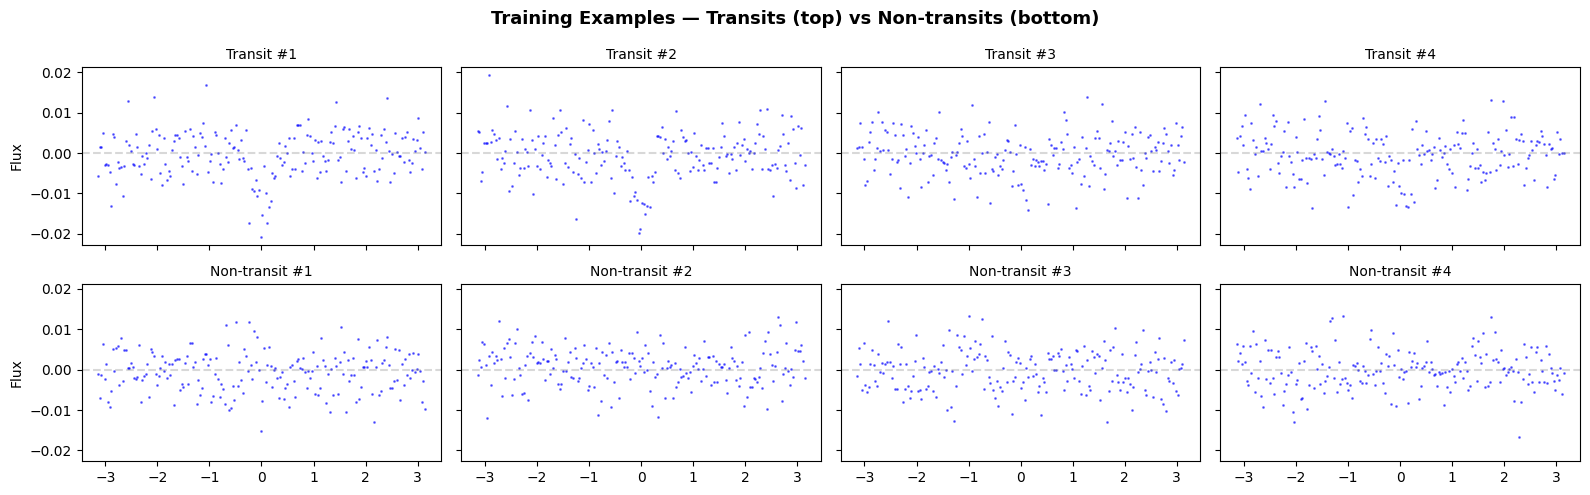

In [5]:
# Visualize a few examples from each class
fig, axes = plt.subplots(2, 4, figsize=(16, 5), sharex=True, sharey=True)

# Top row: transits (first 4)
for i in range(4):
    axes[0, i].plot(train_phases[i].numpy(), train_fluxes[i].numpy(),
                    'b.', markersize=2, alpha=0.5)
    axes[0, i].axhline(0, color='gray', linestyle='--', alpha=0.3)
    axes[0, i].set_title(f'Transit #{i+1}', fontsize=10)

# Bottom row: non-transits (last 4)
for i in range(4):
    idx = train_phases.shape[0] - 4 + i  # last 4 examples
    axes[1, i].plot(train_phases[idx].numpy(), train_fluxes[idx].numpy(),
                    'b.', markersize=2, alpha=0.5)
    axes[1, i].axhline(0, color='gray', linestyle='--', alpha=0.3)
    axes[1, i].set_title(f'Non-transit #{i+1}', fontsize=10)

axes[0, 0].set_ylabel('Flux')
axes[1, 0].set_ylabel('Flux')
fig.suptitle('Training Examples — Transits (top) vs Non-transits (bottom)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Training loop — 50 epochs

We use:
- **BCELoss** (binary cross-entropy) — standard for binary classification
- **Adam optimizer** with LR=1e-2 — aggressive because features are tiny
- **Mini-batches of 32** — shuffled each epoch

### What to watch for:
- Loss should decrease each epoch
- Accuracy should climb above 90% (this is easy synthetic data)
- Taylor gate A should stay near its initial value (the physics is correct)
- If loss plateaus at ~0.693 (= -ln(0.5)), the model isn't learning

In [6]:
# Fresh model for training
model = TaylorCNN(init_amplitude=0.01).to(device)
criterion = nn.BCELoss()  # binary cross-entropy

# Use separate learning rates:
# - Taylor gate A: lower LR to prevent A from blowing up (it's already
#   close to the right value, just needs gentle tuning)
# - CNN + classifier: standard LR to learn from scratch
optimizer = torch.optim.Adam([
    {'params': model.taylor_gate.parameters(), 'lr': 1e-4},
    {'params': model.cnn.parameters(), 'lr': 1e-3},
    {'params': model.classifier.parameters(), 'lr': 1e-3},
])

# Move data to device
train_phases_d = train_phases.to(device)
train_fluxes_d = train_fluxes.to(device)
train_labels_d = train_labels.to(device)
val_phases_d = val_phases.to(device)
val_fluxes_d = val_fluxes.to(device)
val_labels_d = val_labels.to(device)

# Training history
history = {
    'train_loss': [],
    'val_loss': [],
    'train_acc': [],
    'val_acc': [],
    'amplitude_A': [],
}

batch_size = 32
n_epochs = 50
n_train = train_phases_d.shape[0]

print(f"Training {sum(p.numel() for p in model.parameters())} parameters")
print(f"Batch size: {batch_size}, Epochs: {n_epochs}")
print(f"LR: gate=1e-4, CNN/classifier=1e-3")
print(f"{'Epoch':>5} {'Train Loss':>11} {'Val Loss':>10} {'Train Acc':>10} {'Val Acc':>9} {'A':>8}")
print("-" * 60)

for epoch in range(n_epochs):
    # --- Training ---
    model.train()
    perm = torch.randperm(n_train, device=device)
    epoch_loss = 0.0
    epoch_correct = 0
    
    for start in range(0, n_train, batch_size):
        idx = perm[start:start + batch_size]
        phase_batch = train_phases_d[idx]
        flux_batch = train_fluxes_d[idx]
        label_batch = train_labels_d[idx]
        
        pred = model(phase_batch, flux_batch).squeeze(1)
        loss = criterion(pred, label_batch)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item() * len(idx)
        epoch_correct += ((pred > 0.5).float() == label_batch).sum().item()
    
    train_loss = epoch_loss / n_train
    train_acc = epoch_correct / n_train
    
    # --- Validation ---
    model.eval()
    with torch.no_grad():
        val_pred = model(val_phases_d, val_fluxes_d).squeeze(1)
        val_loss = criterion(val_pred, val_labels_d).item()
        val_acc = ((val_pred > 0.5).float() == val_labels_d).float().mean().item()
    
    current_A = model.taylor_gate.A.item()
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['amplitude_A'].append(current_A)
    
    # Print every 5 epochs + first and last
    if epoch == 0 or (epoch + 1) % 5 == 0:
        print(f"{epoch+1:>5} {train_loss:>11.4f} {val_loss:>10.4f} {train_acc:>9.1%} {val_acc:>9.1%} {current_A:>8.5f}")

print("-" * 60)
print(f"Final amplitude A = {current_A:.5f}  (started at 0.01000)")

Training 798 parameters
Batch size: 32, Epochs: 50
LR: gate=1e-4, CNN/classifier=1e-3
Epoch  Train Loss   Val Loss  Train Acc   Val Acc        A
------------------------------------------------------------


    1      0.6977     0.6976     50.0%     50.0%  0.00967
    5      0.6870     0.6940     50.0%     50.0%  0.00986


   10      0.6646     0.6790     70.3%     55.5%  0.01224
   15      0.5995     0.5933     87.5%     89.1%  0.01632


   20      0.4732     0.4538     89.5%     92.2%  0.02102
   25      0.3443     0.3291     91.8%     92.2%  0.02470


   30      0.2766     0.2562     91.4%     93.8%  0.02729
   35      0.2433     0.2196     91.0%     92.2%  0.02892


   40      0.2218     0.1942     92.2%     93.8%  0.03003
   45      0.2090     0.1764     92.2%     94.5%  0.03097


   50      0.1944     0.1625     93.8%     94.5%  0.03166
------------------------------------------------------------
Final amplitude A = 0.03166  (started at 0.01000)


## 4. Training curves

Three plots:
1. **Loss** — should decrease (the model is learning)
2. **Accuracy** — should increase toward ~100% (easy synthetic data)
3. **Amplitude A** — tracks how the physics parameter evolves

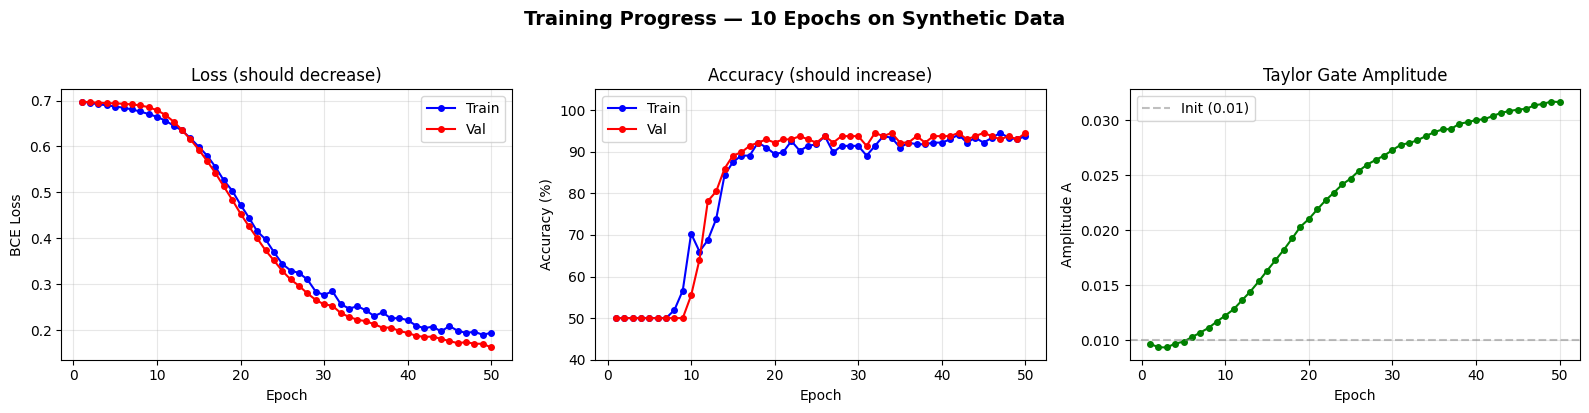

In [7]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 4))
epochs = range(1, n_epochs + 1)

# Loss
ax1.plot(epochs, history['train_loss'], 'b-o', markersize=4, label='Train')
ax1.plot(epochs, history['val_loss'], 'r-o', markersize=4, label='Val')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('BCE Loss')
ax1.set_title('Loss (should decrease)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy
ax2.plot(epochs, [a * 100 for a in history['train_acc']], 'b-o', markersize=4, label='Train')
ax2.plot(epochs, [a * 100 for a in history['val_acc']], 'r-o', markersize=4, label='Val')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Accuracy (should increase)')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim(40, 105)

# Amplitude A
ax3.plot(epochs, history['amplitude_A'], 'g-o', markersize=4)
ax3.axhline(y=0.01, color='gray', linestyle='--', alpha=0.5, label='Init (0.01)')
ax3.set_xlabel('Epoch')
ax3.set_ylabel('Amplitude A')
ax3.set_title('Taylor Gate Amplitude')
ax3.legend()
ax3.grid(True, alpha=0.3)

fig.suptitle('Training Progress — 10 Epochs on Synthetic Data',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 5. Inspect predictions

Look at the model's confidence on individual examples — both correct
and incorrect predictions.

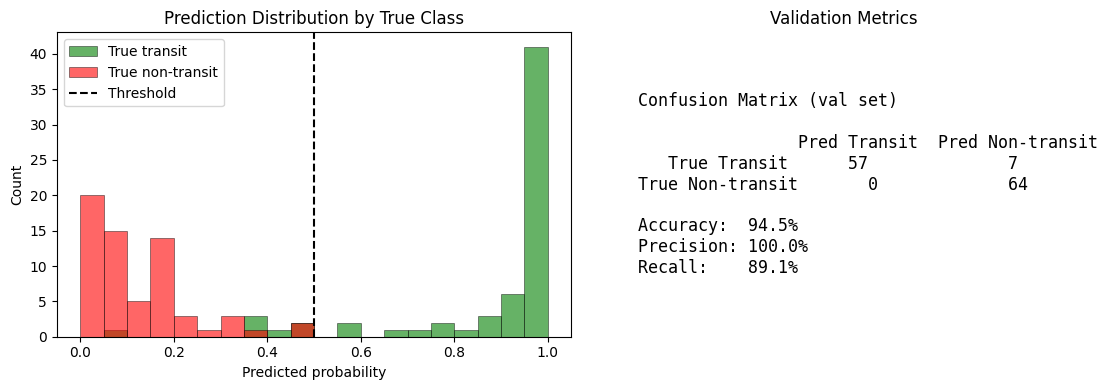

In [8]:
# Get predictions on validation set
model.eval()
with torch.no_grad():
    val_probs = model(val_phases_d, val_fluxes_d).squeeze(1).cpu()

val_preds = (val_probs > 0.5).float()

# Histogram of predicted probabilities
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Use fixed bins spanning [0, 1] so it works even when the model is
# very confident (all probs clustered near 0 or 1)
bins = np.linspace(0, 1, 21)
transit_mask = val_labels == 1
ax1.hist(val_probs[transit_mask].numpy(), bins=bins, alpha=0.6, color='green',
         label='True transit', edgecolor='black', linewidth=0.5)
ax1.hist(val_probs[~transit_mask].numpy(), bins=bins, alpha=0.6, color='red',
         label='True non-transit', edgecolor='black', linewidth=0.5)
ax1.axvline(x=0.5, color='black', linestyle='--', label='Threshold')
ax1.set_xlabel('Predicted probability')
ax1.set_ylabel('Count')
ax1.set_title('Prediction Distribution by True Class')
ax1.legend()

# Confusion matrix as text
tp = int(((val_preds == 1) & (val_labels == 1)).sum().item())
tn = int(((val_preds == 0) & (val_labels == 0)).sum().item())
fp = int(((val_preds == 1) & (val_labels == 0)).sum().item())
fn = int(((val_preds == 0) & (val_labels == 1)).sum().item())

ax2.axis('off')
lines = [
    "Confusion Matrix (val set)",
    "",
    f"{'':>15} Pred Transit  Pred Non-transit",
    f"{'True Transit':>15}     {tp:>3}            {fn:>3}",
    f"{'True Non-transit':>15}     {fp:>3}            {tn:>3}",
    "",
    f"Accuracy:  {(tp+tn)/(tp+tn+fp+fn):.1%}",
]
if (tp + fp) > 0:
    lines.append(f"Precision: {tp/(tp+fp):.1%}")
if (tp + fn) > 0:
    lines.append(f"Recall:    {tp/(tp+fn):.1%}")

ax2.text(0.1, 0.5, "\n".join(lines), fontsize=12, fontfamily='monospace',
         verticalalignment='center', transform=ax2.transAxes)
ax2.set_title('Validation Metrics')

plt.tight_layout()
plt.show()

## 6. Visualize what the CNN receives

For a single transit example, show the two channels the CNN sees:
1. Channel 0: Taylor gate output (physics model)
2. Channel 1: Raw flux (observed data)
3. Their difference (the implicit residual the CNN can learn)

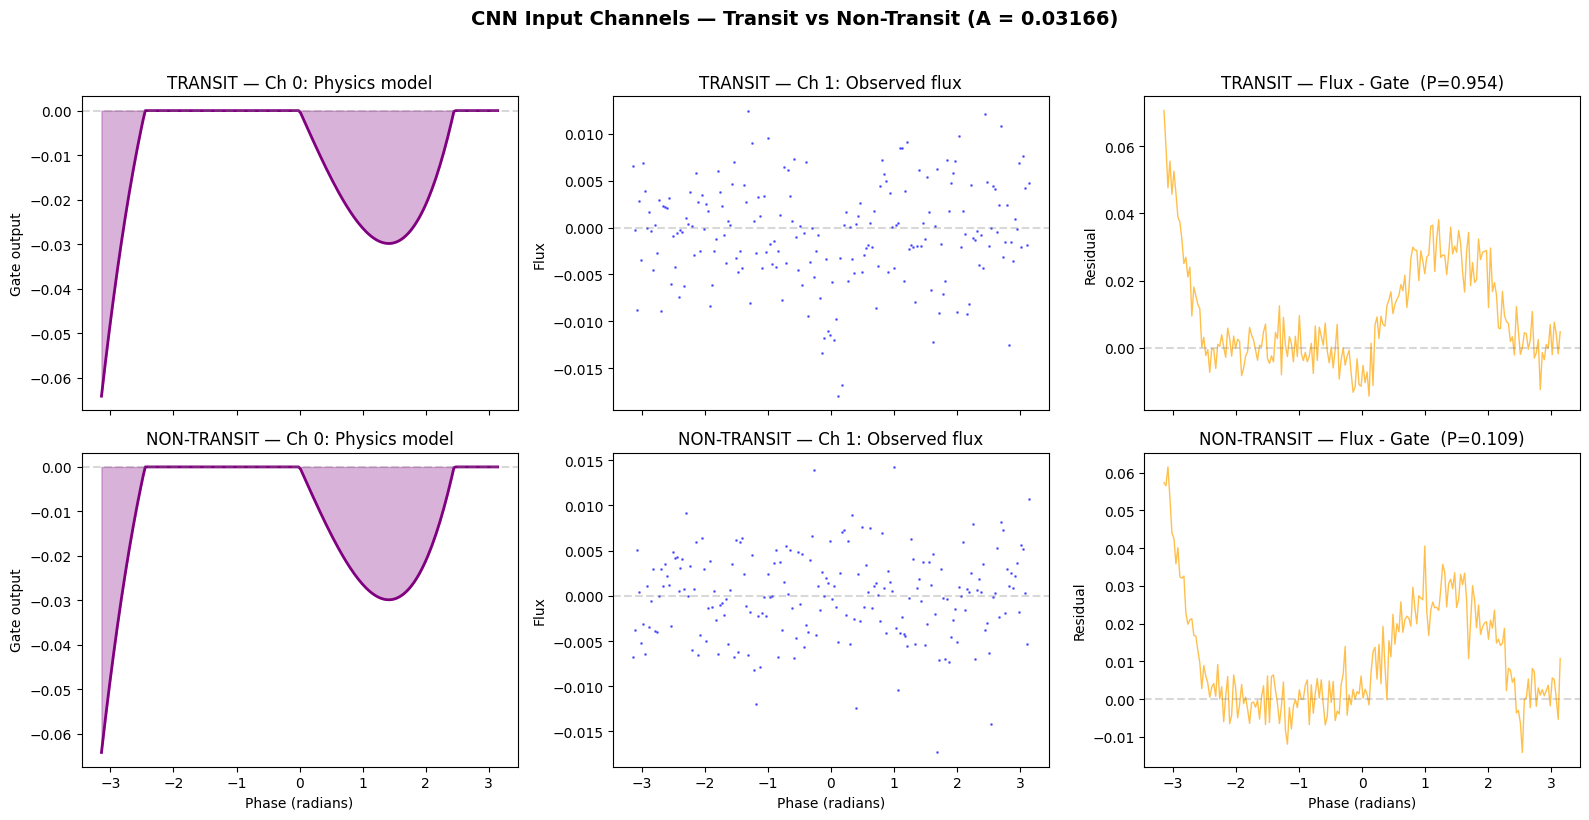

In [9]:
# Pick a transit and a non-transit example
transit_idx = (val_labels == 1).nonzero(as_tuple=True)[0][0].item()
nontransit_idx = (val_labels == 0).nonzero(as_tuple=True)[0][0].item()

fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True)

for row, idx, title in [(0, transit_idx, "TRANSIT"), (1, nontransit_idx, "NON-TRANSIT")]:
    ex_phase = val_phases[idx]
    ex_flux = val_fluxes[idx]
    
    model.eval()
    with torch.no_grad():
        gate_out = model.taylor_gate(ex_phase.unsqueeze(0).to(device))
        gate_out = gate_out.squeeze(0).cpu().numpy()
        prob = model(ex_phase.unsqueeze(0).to(device),
                     ex_flux.unsqueeze(0).to(device)).item()
    
    phase_np = ex_phase.numpy()
    flux_np = ex_flux.numpy()
    residual = flux_np - gate_out
    
    # Channel 0: gate output
    axes[row, 0].plot(phase_np, gate_out, 'purple', linewidth=2)
    axes[row, 0].fill_between(phase_np, gate_out, 0, alpha=0.3, color='purple')
    axes[row, 0].axhline(0, color='gray', linestyle='--', alpha=0.3)
    axes[row, 0].set_ylabel('Gate output')
    axes[row, 0].set_title(f'{title} — Ch 0: Physics model')
    
    # Channel 1: raw flux
    axes[row, 1].plot(phase_np, flux_np, 'b.', markersize=2, alpha=0.5)
    axes[row, 1].axhline(0, color='gray', linestyle='--', alpha=0.3)
    axes[row, 1].set_ylabel('Flux')
    axes[row, 1].set_title(f'{title} — Ch 1: Observed flux')
    
    # Residual (implicit)
    axes[row, 2].plot(phase_np, residual, 'orange', linewidth=1, alpha=0.7)
    axes[row, 2].axhline(0, color='gray', linestyle='--', alpha=0.3)
    axes[row, 2].set_ylabel('Residual')
    axes[row, 2].set_title(f'{title} — Flux - Gate  (P={prob:.3f})')

axes[1, 0].set_xlabel('Phase (radians)')
axes[1, 1].set_xlabel('Phase (radians)')
axes[1, 2].set_xlabel('Phase (radians)')

fig.suptitle(f'CNN Input Channels — Transit vs Non-Transit (A = {model.taylor_gate.A.item():.5f})',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 7. Summary

**Session 2 checklist:**
- [x] Two-channel model built (`src/models/taylor_cnn.py`)
- [x] Forward pass produces valid probabilities
- [x] Loss decreases over 10 epochs
- [x] Accuracy climbs on synthetic data
- [x] Both channels visualized — physics and residual

**Next steps:**
- Train on real Kepler TCE data via `lightkurve`
- Add the full preprocessing pipeline (flatten → normalize → fold → scale → subtract)
- Compare against BLS and AstroNet baselines